# Loading and Displaying Images in .lif in python
a notebook for image loading and display

first we will need to install a few packages, note that the first package is specific to working with .lif files from Leica

In [20]:
pip install readlif

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


...as before we will need to clone the repository into colab so that we can have access to example images

In [22]:
import os
# Clone the repo if not already in Colab
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/NBCimageAnalysis'):
        !git clone https://github.com/FilLieb/NBCimageAnalysis.git
    os.chdir('/content/NBCimageAnalysis/learning/')
    print(os.listdir('.'))

We will be using an example image from 2026...
Note that we are creating the variable lif (we could name it whatever we would like) and we will store the entire .lif file in it...

In [23]:
from readlif.reader import LifFile

# Open the .lif file
lif = LifFile('../data/2026group2/Gruppe2 WT - DMet High Density.lif')


Within .lif files multiple images can be saved. Let's check what's inside this specific file. 

In [24]:
# List all images/series in the file
for img in lif.get_iter_image():
    print(img.name, img.dims)

Image 1 Dims(x=1024, y=1024, z=1, t=1, m=1)
Image 2 Dims(x=1024, y=1024, z=1, t=1, m=1)
Image 3 Dims(x=1024, y=1024, z=1, t=1, m=1)
Image 4 Dims(x=1024, y=1024, z=1, t=1, m=1)
Image 5 Dims(x=1024, y=1024, z=1, t=1, m=1)


Let's checkout the first image (in prgramming this has the index 0). We are creating the variable image and store only the first image inside. 

In [ ]:
# Access a specific image by index
image = lif.get_image(0)

# Get image metadata
print(image.name)        # image name
print(image.dims)        # (x, y, z, t, m) dimensions, m dimension refers to the mosaic tile index
print(image.scale)       # pixel scale (µm/pixel)
print(image.channels)    # number of channels

Image 1
Dims(x=1024, y=1024, z=1, t=1, m=1)
(5.544000286141951, 5.544000286141951, None, None)
4


We can iterate over channels to see the individual objects:

In [31]:
# Iterate over channels (returns PIL Images)
for channel in image.get_iter_c(t=0, z=0):
    print(channel)  # PIL Image object


<PIL.Image.Image image mode=I;16 size=1024x1024 at 0x2236CEAE3F0>
<PIL.Image.Image image mode=I;16 size=1024x1024 at 0x2236EFE11D0>
<PIL.Image.Image image mode=I;16 size=1024x1024 at 0x2236EFE36B0>
<PIL.Image.Image image mode=I;16 size=1024x1024 at 0x2236EFE11D0>


We need to convert the information into something that is commonly used in various image processing packages... a numpy array (to be precise it is a stack of numpy arrays)

In [34]:
import numpy as np

channels_array = np.stack([np.array(channel) for channel in image.get_iter_c(t=0, z=0)])

print(channels_array.shape)  # (channels, height, width)

(4, 1024, 1024)


We can display the first channel using matplotlib:

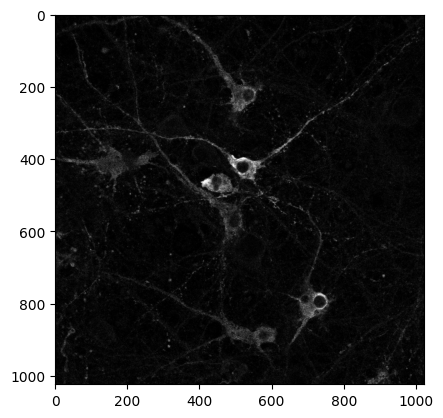

In [40]:
import matplotlib.pyplot as plt

plt.imshow(channels_array[0], cmap='gray')  # Display the first channel

Let's check all the channels in one figure

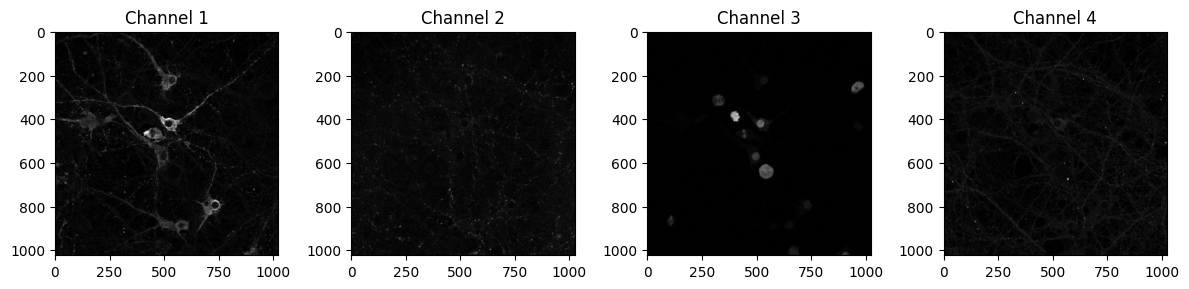

In [41]:
# make a quick figure to display individual channels
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

axes[0].imshow(channels_array[0], cmap='gray')
axes[0].set_title("Channel 1")

axes[1].imshow(channels_array[1], cmap='gray')
axes[1].set_title("Channel 2")

axes[2].imshow(channels_array[2], cmap='gray')
axes[2].set_title("Channel 3")

axes[3].imshow(channels_array[3], cmap='gray')
axes[3].set_title("Channel 4")

plt.tight_layout()
plt.show()

The order of channels, should become clear from this image, to be sure let's go back to Fiji to compare. 

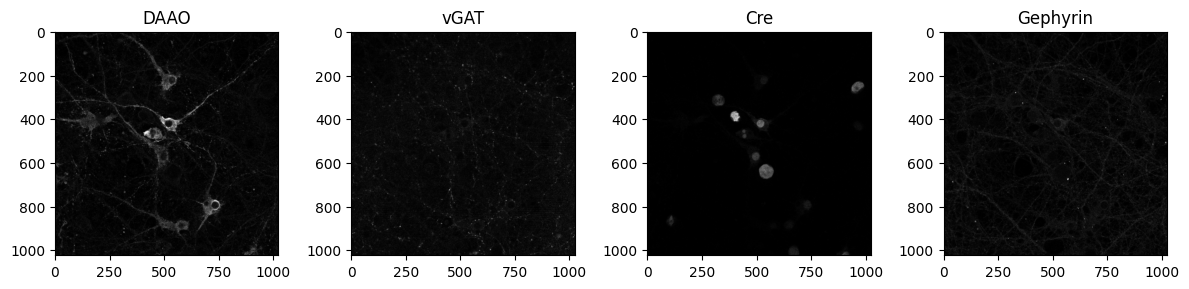

In [42]:
# make a quick figure to display individual channels
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

axes[0].imshow(channels_array[0], cmap='gray')
axes[0].set_title("DAAO")

axes[1].imshow(channels_array[1], cmap='gray')
axes[1].set_title("vGAT")

axes[2].imshow(channels_array[2], cmap='gray')
axes[2].set_title("Cre")

axes[3].imshow(channels_array[3], cmap='gray')
axes[3].set_title("Gephyrin")

plt.tight_layout()
plt.show()